# 🌫️ Prediksi AQI 30 Hari ke Depan dengan LSTM Multivariate
### Kelompok 7 — Data Mining & Machine Learning


## 1. Install Library & Import

In [ ]:
import sys
import os
sys.path.insert(0, '..')   # insert di posisi 0 agar src/ diutamakan (bukan append)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     BatchNormalization, Bidirectional)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.optimizers import Adam

from src.utils import evaluate_model, log_experiment

## 2. Load Dataset

In [ ]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Jalankan dari folder notebooks/ — path relatif ke root repo
df = pd.read_csv('../AQI Bangladesh.csv')

print(f"Shape    : {df.shape}")
print(f"Kolom    : {list(df.columns)}")
df.head()

In [ ]:
# ── Info dataset ──────────────────────────────────────────────────────────────
print(df.dtypes)
print(f"\nMissing value:\n{df.isnull().sum()}")

city_id               int64
city_name            object
lat                 float64
lon                 float64
datetime             object
pm10                float64
pm2_5               float64
carbon_monoxide     float64
carbon_dioxide      float64
nitrogen_dioxide    float64
sulphur_dioxide     float64
ozone               float64
aqi                 float64
dtype: object

Missing value:
city_id                  0
city_name                0
lat                      0
lon                      0
datetime                 0
pm10                     0
pm2_5                    0
carbon_monoxide          0
carbon_dioxide      774327
nitrogen_dioxide         0
sulphur_dioxide          0
ozone                    0
aqi                    696
dtype: int64


## 3. Exploratory Data Analysis (EDA)

EDA difokuskan pada hal-hal yang langsung relevan untuk LSTM:
tren AQI, distribusi, pola jam, dan korelasi antar fitur.

In [ ]:
# ── Parse datetime ───────────────────────────────────────────────────────────
df['datetime'] = pd.to_datetime(df['datetime'])

pollutant_cols = ['pm10', 'pm2_5', 'carbon_monoxide',
                  'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']

print(f"Rentang waktu : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Jumlah kota   : {df['city_name'].nunique()}")
print(f"Total record  : {len(df):,}")

Rentang waktu : 2000-01-01 00:00:00 → 2025-11-23 23:00:00
Jumlah kota   : 30
Total record  : 1,048,551


In [ ]:
# ── Statistik deskriptif polutan + AQI ───────────────────────────────────────
df.describe()

,city_id,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
count,1.048551e+06,1.048551e+06,1.048551e+06,1048551,1.048551e+06,1.048551e+06,1.048551e+06,274224.000000,1.048551e+06,1.048551e+06,1.048551e+06,1.047855e+06
mean,1.724447e+06,2.368415e+01,9.048250e+01,2021-10-15 01:40:43.493162240,7.497350e+01,5.067619e+01,3.235187e+02,456.900698,1.678140e+01,9.784067e+00,7.378080e+01,1.150751e+02
min,1.185100e+06,2.143973e+01,8.863779e+01,2000-01-01 00:00:00,2.000000e-01,1.000000e-01,1.000000e-01,408.000000,-1.000000e-01,0.000000e+00,-3.000000e+00,9.000000e+00
25%,1.185241e+06,2.301440e+01,9.006273e+01,2022-11-01 01:00:00,2.630000e+01,1.900000e+01,1.550000e+02,444.000000,4.400000e+00,2.900000e+00,4.500000e+01,6.800000e+01
50%,1.185263e+06,2.371040e+01,9.040744e+01,2023-11-01 17:00:00,5.610000e+01,3.990000e+01,2.720000e+02,452.000000,1.070000e+01,6.600000e+00,6.400000e+01,1.170000e+02
75%,1.209562e+06,2.407821e+01,9.097640e+01,2024-11-12 08:00:00,9.990000e+01,6.960000e+01,4.510000e+02,464.000000,2.440000e+01,1.420000e+01,9.400000e+01,1.572355e+02
max,7.921384e+06,2.567419e+01,9.221946e+01,2025-11-23 23:00:00,7.879000e+02,5.513000e+02,5.084000e+03,740.000000,1.780000e+02,1.724000e+02,3.280000e+02,2.995996e+02
std,1.702309e+06,9.928910e-01,8.652851e-01,NaN,6.744548e+01,4.186072e+01,2.804124e+02,20.958356,1.734989e+01,9.302039e+00,4.104232e+01,5.262795e+01


In [ ]:
# ── Tren AQI harian per kota (EDA — tidak memodifikasi df) ───────────────────
# datetime sudah di-parse di sel sebelumnya (GwG2CoTs1Mb0)
df_ts = df.set_index('datetime')

daily_aqi = (
    df_ts.groupby('city_name')['aqi']
    .resample('D')
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 5))

for city in daily_aqi['city_name'].unique():
    d = daily_aqi[daily_aqi['city_name'] == city]
    ax.plot(d['datetime'], d['aqi'], linewidth=1)

ax.set_title('Tren AQI Harian per Kota (2000–2025)')
ax.set_xlabel('Tanggal')
ax.set_ylabel('AQI')

plt.tight_layout()
plt.show()

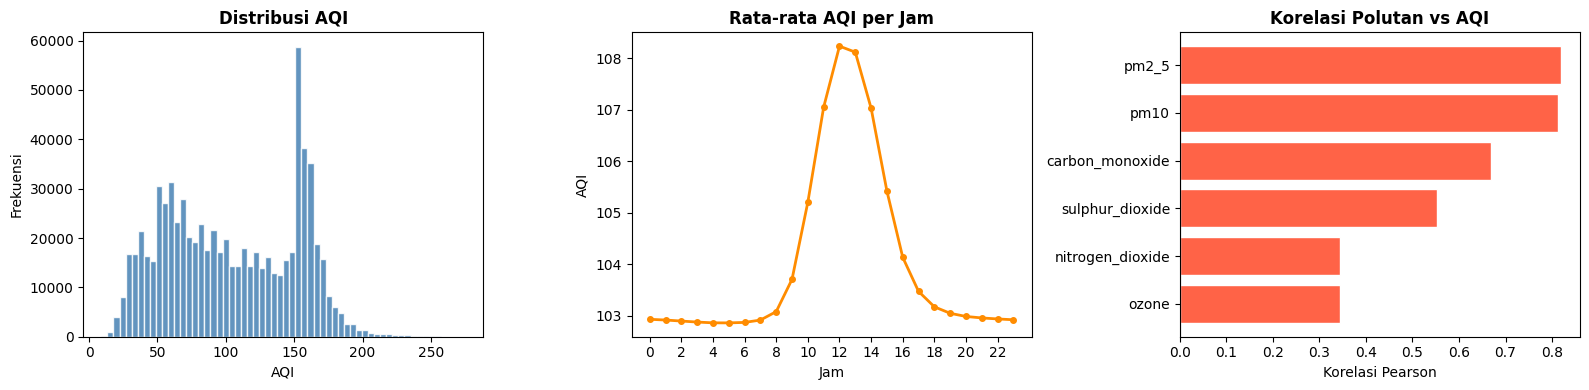

In [ ]:
# ── Pola jam & distribusi ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribusi AQI
axes[0].hist(df['aqi'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi AQI', fontweight='bold')
axes[0].set_xlabel('AQI'); axes[0].set_ylabel('Frekuensi')

# Pola per jam
hourly = df.groupby(df['datetime'].dt.hour)['aqi'].mean()
axes[1].plot(hourly.index, hourly.values, color='darkorange', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Rata-rata AQI per Jam', fontweight='bold')
axes[1].set_xlabel('Jam'); axes[1].set_ylabel('AQI')
axes[1].set_xticks(range(0, 24, 2))

# Korelasi polutan-AQI
corr = df[pollutant_cols + ['aqi']].corr()['aqi'].drop('aqi').sort_values()
bars = axes[2].barh(corr.index, corr.values,
                    color=['tomato' if v > 0 else 'steelblue' for v in corr.values],
                    edgecolor='white')
axes[2].set_title('Korelasi Polutan vs AQI', fontweight='bold')
axes[2].set_xlabel('Korelasi Pearson')
axes[2].axvline(0, color='gray', linewidth=0.8)

plt.tight_layout(); plt.show()

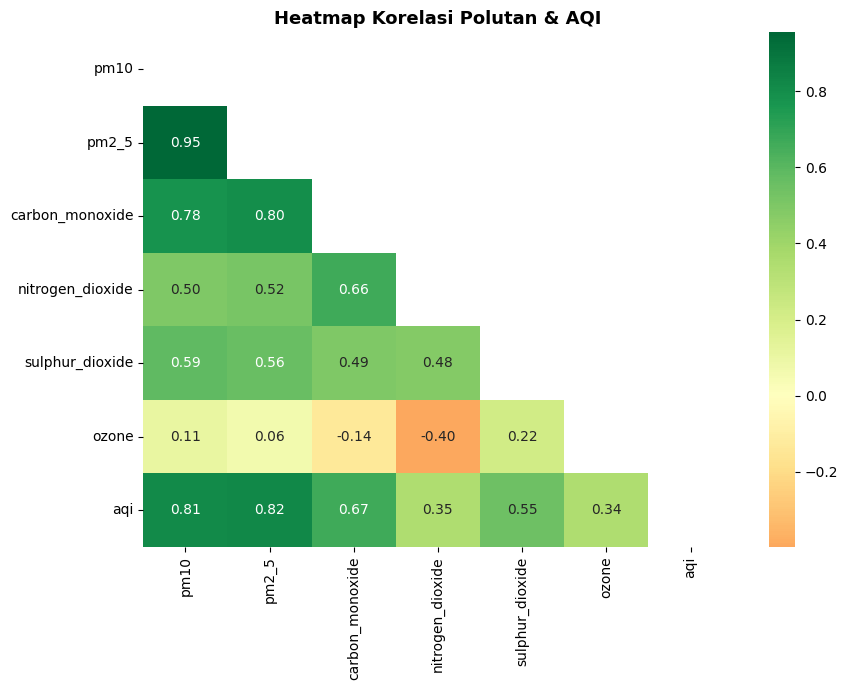

In [ ]:
# ── Heatmap korelasi ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df[pollutant_cols + ['aqi']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Heatmap Korelasi Polutan & AQI', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

## 4. Data Cleaning

In [ ]:
# ── Filter data: gunakan 2023 ke atas untuk feasibility ──────────────────────
# Dataset lengkap 25 tahun terlalu besar untuk Colab — ambil 2023–2025 saja.
df_clean = df[df['datetime'].dt.year >= 2023].copy()

# Hapus kolom tak relevan jika ada
df_clean.drop(columns=['aqi_category'], errors='ignore', inplace=True)

# Parse datetime & urutkan
df_clean['datetime'] = pd.to_datetime(df_clean['datetime'])
df_clean.sort_values(['city_name', 'datetime'], inplace=True)

# Hapus duplikasi
df_clean.drop_duplicates(subset=['city_id', 'datetime'], inplace=True)

# Ganti nilai negatif jadi NaN
for col in pollutant_cols:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

print(f"Shape setelah filter 2023+: {df_clean.shape}")

In [ ]:
# Winsorizing outlier per kota
for col in pollutant_cols:
    q1 = df_clean.groupby('city_name')[col].transform(lambda x: x.quantile(0.01))
    q99 = df_clean.groupby('city_name')[col].transform(lambda x: x.quantile(0.99))
    df_clean[col] = df_clean[col].clip(q1, q99)

In [ ]:
# ── Drop carbon_dioxide jika missing > 50% ───────────────────────────────────
if 'carbon_dioxide' in df_clean.columns:
    co2_missing = df_clean['carbon_dioxide'].isnull().mean() * 100
    print(f"carbon_dioxide missing: {co2_missing:.1f}%")
    if co2_missing > 50:
        df_clean = df_clean.drop(columns=['carbon_dioxide'])
        pollutant_cols = [c for c in pollutant_cols if c != 'carbon_dioxide']
        print("  → Kolom carbon_dioxide di-drop")

# ── Drop baris tanpa AQI target ───────────────────────────────────────────────
n_before = len(df_clean)
df_clean = df_clean.dropna(subset=['aqi'])
print(f"Baris tanpa AQI dihapus : {n_before - len(df_clean):,}")

# ── Interpolasi linear per kota untuk polutan ────────────────────────────────
df_clean = df_clean.groupby('city_name', group_keys=False).apply(
    lambda g: g.set_index('datetime').interpolate(method='time').reset_index()
)
df_clean = df_clean.sort_values(['city_name','datetime']).reset_index(drop=True)
print(f"✅ Cleaning selesai. Shape: {df_clean.shape}")
print(f"   Missing setelah: {df_clean[pollutant_cols + ['aqi']].isnull().sum().sum()}")

carbon_dioxide missing: 63.1%
  → Kolom carbon_dioxide di-drop
Baris tanpa AQI dihapus : 0
✅ Cleaning selesai. Shape: (742551, 12)
   Missing setelah: 0


## 5. Feature Engineering

Fitur dibuat agar LSTM mendapat konteks temporal yang kaya:
- **Cyclical encoding** (hour, month, dayofweek)
- **Lag features** (1, 3, 6, 24 jam lalu)
- **Rolling statistics** (mean & std, window 3, 6, 24 jam)
- **Interaksi polutan** (pm_ratio, pm_total, oxidant_load, combustion_idx)

In [ ]:
df_feat = df_clean.copy()

# ── Fitur temporal ────────────────────────────────────────────────────────────
df_feat['hour']       = df_feat['datetime'].dt.hour
df_feat['day']        = df_feat['datetime'].dt.day
df_feat['month']      = df_feat['datetime'].dt.month
df_feat['dayofweek']  = df_feat['datetime'].dt.dayofweek
df_feat['dayofyear']  = df_feat['datetime'].dt.dayofyear
df_feat['is_weekend'] = (df_feat['dayofweek'] >= 5).astype(int)
df_feat['quarter']    = df_feat['datetime'].dt.quarter

# Cyclical encoding (tidak ada urutan linear yang terputus)
df_feat['hour_sin']  = np.sin(2 * np.pi * df_feat['hour']      / 24)
df_feat['hour_cos']  = np.cos(2 * np.pi * df_feat['hour']      / 24)
df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month']     / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month']     / 12)
df_feat['dow_sin']   = np.sin(2 * np.pi * df_feat['dayofweek'] / 7)
df_feat['dow_cos']   = np.cos(2 * np.pi * df_feat['dayofweek'] / 7)

# Musim Bangladesh
def get_season(month):
    if month in [12,1,2]:      return 0  # winter
    elif month in [3,4,5]:     return 1  # pre_monsoon
    elif month in [6,7,8,9]:   return 2  # monsoon
    else:                      return 3  # post_monsoon
df_feat['season_code'] = df_feat['month'].apply(get_season)

print(f"Fitur temporal : {df_feat.shape[1] - df_clean.shape[1]} kolom baru")

Fitur temporal : 14 kolom baru


In [ ]:
# ── Lag & Rolling features ────────────────────────────────────────────────────
lag_cols = pollutant_cols + ['aqi']

def create_lag_rolling(group):
    group = group.sort_values('datetime')
    for col in lag_cols:
        for lag in [1, 3, 6, 24]:
            group[f'{col}_lag{lag}'] = group[col].shift(lag)
        for win in [3, 6, 24]:
            group[f'{col}_roll{win}m']   = group[col].shift(1).rolling(win, min_periods=1).mean()
            group[f'{col}_roll{win}std'] = group[col].shift(1).rolling(win, min_periods=1).std().fillna(0)
    return group

print("Membuat fitur lag & rolling...")
df_feat = df_feat.groupby('city_name', group_keys=False).apply(create_lag_rolling)
print(f"Total kolom setelah lag/rolling: {df_feat.shape[1]}")

Membuat fitur lag & rolling...
Total kolom setelah lag/rolling: 96


In [ ]:
# ── Interaksi polutan ─────────────────────────────────────────────────────────
# Untuk LSTM, interaksi dibuat dari nilai polutan waktu t (bukan lag1 seperti XGBoost)
# karena temporal dependency ditangani oleh sliding window LOOK_BACK.
#
# Definisi konsisten dengan CLAUDE.md dan src/features.py:
#   pm_ratio      = PM2.5 / (PM10 + ε)            — fraksi partikel halus
#   pm_total      = PM10 + PM2.5                   — beban partikel total
#   oxidant_load  = NO₂ + O₃                       — beban oksidan
#   combustion_idx = CO / (NO₂ + ε)               — indikator pembakaran tidak sempurna

eps = 1e-8
df_feat['pm_ratio']       = df_feat['pm2_5'] / (df_feat['pm10'] + eps)
df_feat['pm_total']       = df_feat['pm10'] + df_feat['pm2_5']
df_feat['oxidant_load']   = df_feat['nitrogen_dioxide'] + df_feat['ozone']
df_feat['combustion_idx'] = df_feat['carbon_monoxide'] / (df_feat['nitrogen_dioxide'] + eps)

# ── Drop lag NaN ──────────────────────────────────────────────────────────────
n_before = len(df_feat)
lag24_cols = [c for c in df_feat.columns if 'lag24' in c]
df_feat = df_feat.dropna(subset=lag24_cols).reset_index(drop=True)
print(f"Baris lag-NaN dihapus : {n_before - len(df_feat):,}")
print(f"Shape akhir           : {df_feat.shape}")

In [ ]:
# ── Label encoding city_name ──────────────────────────────────────────────────
le_city = LabelEncoder()
df_feat['city_encoded'] = le_city.fit_transform(df_feat['city_name'])
print(f"City mapping: {dict(zip(le_city.classes_, le_city.transform(le_city.classes_)))}")

City mapping: {'Azimpur': np.int64(0), 'Badarganj': np.int64(1), 'Baniachang': np.int64(2), 'Barisāl': np.int64(3), 'Bera': np.int64(4), 'Bhairab Bāzār': np.int64(5), 'Bherāmāra': np.int64(6), 'Bhola': np.int64(7), 'Bhāndāria': np.int64(8), 'Bhātpāra Abhaynagar': np.int64(9), 'Bogra': np.int64(10), 'Burhānuddin': np.int64(11), 'Bājitpur': np.int64(12), 'Bāndarban': np.int64(13), 'Char Bhadrāsan': np.int64(14), 'Chhāgalnāiya': np.int64(15), 'Chhātak': np.int64(16), 'Chilmāri': np.int64(17), 'Chittagong': np.int64(18), 'Comilla': np.int64(19), 'Cox’s Bāzār': np.int64(20), 'Dhaka': np.int64(21), 'Dinājpur': np.int64(22), 'Dohār': np.int64(23), 'Farīdpur': np.int64(24), 'Fatikchari': np.int64(25), 'Feni': np.int64(26), 'Gafargaon': np.int64(27), 'Gaibandha': np.int64(28), 'Gaurnadi': np.int64(29)}


## 6. Persiapan Data untuk LSTM

### Strategi:
- **Data**: semua kota (multi-city global model), 6 bulan terakhir untuk feasibility
- **Granularitas**: per jam (hourly) — fitur lag & cyclical tetap bermakna
- **Split**: 80% train / 20% test (**time-aware** — sort by datetime, bukan by city)
- **Forecasting horizon**: 30 hari = 720 jam

In [ ]:
# ── Gunakan 6 bulan terakhir (semua kota) ────────────────────────────────────
cutoff = df_feat['datetime'].max() - pd.DateOffset(months=6)

df_city = (
    df_feat[df_feat['datetime'] >= cutoff]
    .reset_index(drop=True)
)

# Kota dengan data terbanyak (untuk labeling visualisasi)
top_city = df_city.groupby('city_name').size().idxmax()

print(f"Rentang      : {df_city['datetime'].min()} → {df_city['datetime'].max()}")
print(f"Total record : {len(df_city):,}")
print(f"Jumlah kota  : {df_city['city_name'].nunique()}")
print(f"Top city     : {top_city} (digunakan untuk label visualisasi)")

In [ ]:
# ── Definisi fitur ────────────────────────────────────────────────────────────
COLS_EXCLUDE = ['datetime','city_id','city_name','lat','lon','aqi',
                'aqi_category','year']
TARGET = 'aqi'

FEATURES = [c for c in df_city.columns
            if c not in COLS_EXCLUDE
            and df_city[c].dtype in ['float64','int64','int32','int8','uint8']]

print(f"Jumlah fitur : {len(FEATURES)}")
print(f"Target       : {TARGET}")

# Drop baris dengan NaN di fitur/target
df_model = df_city[FEATURES + [TARGET, 'datetime']].dropna().reset_index(drop=True)
print(f"Record bersih: {len(df_model):,}")

Jumlah fitur : 95
Target       : aqi
Record bersih: 128,093


In [ ]:
# ── Time-aware split 80/20 ────────────────────────────────────────────────────
# PENTING: sort by datetime (bukan city_name) agar split benar-benar kronologis
df_model = df_model.sort_values('datetime').reset_index(drop=True)

split_idx = int(len(df_model) * 0.8)
train_df  = df_model.iloc[:split_idx].copy()
test_df   = df_model.iloc[split_idx:].copy()

print(f"Train : {len(train_df):,} record  ({train_df['datetime'].min().date()} → {train_df['datetime'].max().date()})")
print(f"Test  : {len(test_df):,}  record  ({test_df['datetime'].min().date()} → {test_df['datetime'].max().date()})")

In [ ]:
# ── Scaling ────────────────────────────────────────────────────────────────────
# RobustScaler untuk fitur (tahan outlier)
# MinMaxScaler untuk target AQI agar LSTM konvergen lebih stabil

binary_cols = [c for c in FEATURES if df_model[c].nunique() <= 2]
scale_cols  = [c for c in FEATURES if c not in binary_cols]

scaler_X = RobustScaler()
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train = train_df[FEATURES].values.copy()
X_test  = test_df[FEATURES].values.copy()
y_train = train_df[TARGET].values.reshape(-1, 1)
y_test  = test_df[TARGET].values.reshape(-1, 1)

# Indeks kolom yang perlu di-scale
scale_idx = [FEATURES.index(c) for c in scale_cols]
X_train[:, scale_idx] = scaler_X.fit_transform(X_train[:, scale_idx])
X_test[:, scale_idx]  = scaler_X.transform(X_test[:, scale_idx])

y_train_sc = scaler_y.fit_transform(y_train).flatten()
y_test_sc  = scaler_y.transform(y_test).flatten()

print(f"✅ Scaling selesai")
print(f"   X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"   y_train : {y_train_sc.shape}  |  y_test : {y_test_sc.shape}")

✅ Scaling selesai
   X_train : (102474, 95)  |  X_test : (25619, 95)
   y_train : (102474,)  |  y_test : (25619,)


## 7. Membuat Sequence LSTM (Sliding Window)

LSTM membutuhkan input dalam bentuk sequence `(samples, timesteps, features)`.

**LOOK_BACK = 48 jam** (2 hari) → LSTM melihat 48 jam terakhir untuk memprediksi 1 jam berikutnya.

> Kenapa 48? AQI memiliki pola harian (24 jam) dan pengaruh multi-hari dari kondisi cuaca.
> 48 jam mencakup 2 siklus harian sekaligus — cukup untuk menangkap pola tanpa terlalu berat di memori.

In [ ]:
LOOK_BACK = 48  # 2 hari × 24 jam = 48 jam

def make_sequences(X, y, look_back):
    """
    Buat sliding window sequence.
    Input  : X (N, features), y (N,)
    Output : Xs (N-look_back, look_back, features), ys (N-look_back,)
    """
    Xs, ys = [], []
    for i in range(look_back, len(X)):
        Xs.append(X[i - look_back:i])   # (look_back, n_features)
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_seq_tr, y_seq_tr = make_sequences(X_train, y_train_sc, LOOK_BACK)

# Untuk test: sambung ekor train agar sequence pertama valid
X_combined = np.concatenate([X_train, X_test], axis=0)
y_combined = np.concatenate([y_train_sc, y_test_sc], axis=0)
X_seq_all, y_seq_all = make_sequences(X_combined, y_combined, LOOK_BACK)
X_seq_te = X_seq_all[-len(y_test_sc):]
y_seq_te = y_seq_all[-len(y_test_sc):]

n_features = X_seq_tr.shape[2]

print(f"LOOK_BACK      : {LOOK_BACK} jam ({LOOK_BACK // 24} hari)")
print(f"n_features     : {n_features}")
print(f"X_seq_tr shape : {X_seq_tr.shape}   → (samples, timesteps, features)")
print(f"X_seq_te shape : {X_seq_te.shape}")
print(f"y_seq_tr shape : {y_seq_tr.shape}")

## 8. Arsitektur LSTM

**Desain:** 3-layer Bidirectional LSTM + BatchNormalization + Dropout

| Layer | Unit | Keterangan |
|---|---|---|
| BiLSTM 1 | 128×2 | Tangkap pola maju & mundur |
| BiLSTM 2 | 64×2  | Abstraksi lebih dalam |
| LSTM 3   | 32    | Reduksi ke representasi akhir |
| Dense    | 16    | Non-linear projection |
| Output   | 1     | Prediksi AQI (skala 0–1) |

**Bidirectional LSTM** dipilih karena pada fase training, model dapat belajar dari konteks dua arah, sehingga representasi internal yang terbentuk lebih kaya.


In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

def build_lstm_model(look_back, n_features, learning_rate=1e-3):
    model = Sequential([
        # Layer 1: Bidirectional LSTM — tangkap pola dari dua arah
        Bidirectional(LSTM(128, return_sequences=True),
                      input_shape=(look_back, n_features)),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 2: Bidirectional LSTM — abstraksi lebih dalam
        Bidirectional(LSTM(64, return_sequences=True)),
        BatchNormalization(),
        Dropout(0.2),

        # Layer 3: LSTM terakhir — hasilkan representasi sequence
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),

        # Dense head
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # sigmoid → output dalam [0,1] sesuai MinMaxScaler
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss='huber',             # robust terhadap outlier AQI ekstrem
        metrics=['mae']
    )
    return model

lstm_model = build_lstm_model(LOOK_BACK, n_features)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       229,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 48, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,601 (1.59 MB)

 Trainable params: 416,769 (1.59 MB)

 Non-trainable params: 832 (3.25 KB)

## 9. Training LSTM

In [ ]:
# ── Buat direktori output ──────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('artifacts', exist_ok=True)

# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=6,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'models/best_lstm_aqi.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print("✅ Callbacks siap:")
print("   EarlyStopping    : patience=12, restore best weights")
print("   ReduceLROnPlateau: factor=0.4, patience=6")
print("   ModelCheckpoint  : simpan model terbaik ke 'models/best_lstm_aqi.h5'")

In [ ]:
# ── Training ────────────────────────────────────────────────────────────────
history = lstm_model.fit(
    X_seq_tr, y_seq_tr,
    validation_split=0.15,
    epochs=150,
    batch_size=64,
    callbacks=callbacks,
    shuffle=False,   # PENTING: jangan shuffle untuk time-series
    verbose=1
)

print(f"\n✅ Training selesai pada epoch {len(history.history['loss'])}")

Epoch 1/150
1360/1361 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0117 - mae: 0.1099

1361/1361 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - loss: 0.0055 - mae: 0.0753 - val_loss: 0.0059 - val_mae: 0.0720 - learning_rate: 0.0010
Epoch 2/150
1359/1361 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0021 - mae: 0.0493

1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - loss: 0.0018 - mae: 0.0457 - val_loss: 0.0044 - val_mae: 0.0628 - learning_rate: 0.0010
Epoch 3/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - loss: 0.0014 - mae: 0.0392 - val_loss: 0.0044 - val_mae: 0.0604 - learning_rate: 0.0010
Epoch 4/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0013 - mae: 0.0379

1361/1361 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - loss: 0.0011 - mae: 0.0353 - val_loss: 0.0022 - val_mae: 0.0439 - learning_rate: 0.0010
Epoch 5/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - loss: 0.0010 - mae: 0.0338 - val_loss: 0.0029 - val_mae: 0.0502 - learning_rate: 0.0010
Epoch 6/150
1360/1361 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.5819e-04 - mae: 0.0325

1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - loss: 8.2974e-04 - mae: 0.0303 - val_loss: 0.0021 - val_mae: 0.0406 - learning_rate: 0.0010
Epoch 7/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 8.3538e-04 - mae: 0.0303 - val_loss: 0.0032 - val_mae: 0.0512 - learning_rate: 0.0010
Epoch 8/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - loss: 7.1764e-04 - mae: 0.0281 - val_loss: 0.0034 - val_mae: 0.0529 - learning_rate: 0.0010
Epoch 9/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - loss: 6.6878e-04 - mae: 0.0271 - val_loss: 0.0025 - val_mae: 0.0455 - learning_rate: 0.0010
Epoch 10/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 7.3005e-04 - mae: 0.0279

...

1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - loss: 2.3621e-04 - mae: 0.0156 - val_loss: 4.2792e-04 - val_mae: 0.0177 - learning_rate: 1.6000e-04
Epoch 36/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 2.3072e-04 - mae: 0.0154 - val_loss: 4.3383e-04 - val_mae: 0.0183 - learning_rate: 1.6000e-04
Epoch 37/150
1360/1361 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.4151e-04 - mae: 0.0157

1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - loss: 2.2453e-04 - mae: 0.0152 - val_loss: 4.1252e-04 - val_mae: 0.0176 - learning_rate: 1.6000e-04
Epoch 38/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - loss: 2.2265e-04 - mae: 0.0151 - val_loss: 4.2352e-04 - val_mae: 0.0176 - learning_rate: 1.6000e-04
Epoch 39/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - loss: 2.1677e-04 - mae: 0.0149 - val_loss: 4.2705e-04 - val_mae: 0.0176 - learning_rate: 1.6000e-04
Epoch 40/150
1360/1361 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.2551e-04 - mae: 0.0152
Epoch 40: ReduceLROnPlateau reducing learning rate to 6.40000042039901e-05.
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 2.1418e-04 - mae: 0.0149 - val_loss: 4.4814e-04 - val_mae: 0.0180 - learning_rate: 1.6000e-04
Epoch 41/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - loss: 2.1546e-04 - mae: 0.0149 - val_loss: 4.1465e-04 - val_mae: 0.0174 - learning_rate: 6.4000e-05
Epoch 42/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - 

1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - loss: 2.1089e-04 - mae: 0.0147 - val_loss: 3.8034e-04 - val_mae: 0.0170 - learning_rate: 6.4000e-05
Epoch 46/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.1960e-04 - mae: 0.0150
Epoch 46: ReduceLROnPlateau reducing learning rate to 2.560000284574926e-05.
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - loss: 2.0783e-04 - mae: 0.0146 - val_loss: 3.8696e-04 - val_mae: 0.0171 - learning_rate: 6.4000e-05
Epoch 47/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 2.0293e-04 - mae: 0.0146 - val_loss: 3.8652e-04 - val_mae: 0.0168 - learning_rate: 2.5600e-05
Epoch 48/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - loss: 2.0541e-04 - mae: 0.0146 - val_loss: 3.9010e-04 - val_mae: 0.0169 - learning_rate: 2.5600e-05
Epoch 49/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 2.0635e-04 - mae: 0.0145 - val_loss: 3.8457e-04 - val_mae: 0.0168 - learning_rate: 2.5600e-05
Epoch 50/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step -

1361/1361 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - loss: 2.0338e-04 - mae: 0.0146 - val_loss: 3.7886e-04 - val_mae: 0.0165 - learning_rate: 2.5600e-05
Epoch 53/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 2.0264e-04 - mae: 0.0147 - val_loss: 3.8002e-04 - val_mae: 0.0167 - learning_rate: 1.0240e-05
Epoch 54/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - loss: 2.0468e-04 - mae: 0.0146 - val_loss: 3.8046e-04 - val_mae: 0.0167 - learning_rate: 1.0240e-05
Epoch 55/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - loss: 2.0690e-04 - mae: 0.0147 - val_loss: 3.7984e-04 - val_mae: 0.0167 - learning_rate: 1.0240e-05
Epoch 56/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - loss: 2.0343e-04 - mae: 0.0146 - val_loss: 3.8060e-04 - val_mae: 0.0168 - learning_rate: 1.0240e-05
Epoch 57/150
1360/1361 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.2352e-04 - mae: 0.0153

1361/1361 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - loss: 2.0708e-04 - mae: 0.0146 - val_loss: 3.7447e-04 - val_mae: 0.0166 - learning_rate: 1.0240e-05
Epoch 58/150
1360/1361 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.1919e-04 - mae: 0.0152
Epoch 58: ReduceLROnPlateau reducing learning rate to 4.09600033890456e-06.
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - loss: 2.0398e-04 - mae: 0.0147 - val_loss: 3.7791e-04 - val_mae: 0.0167 - learning_rate: 1.0240e-05
Epoch 59/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - loss: 2.1093e-04 - mae: 0.0149 - val_loss: 3.8136e-04 - val_mae: 0.0172 - learning_rate: 4.0960e-06
Epoch 60/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - loss: 2.1038e-04 - mae: 0.0149 - val_loss: 3.8106e-04 - val_mae: 0.0173 - learning_rate: 4.0960e-06
Epoch 61/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - loss: 2.0552e-04 - mae: 0.0148 - val_loss: 3.8158e-04 - val_mae: 0.0173 - learning_rate: 4.0960e-06
Epoch 62/150
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - 

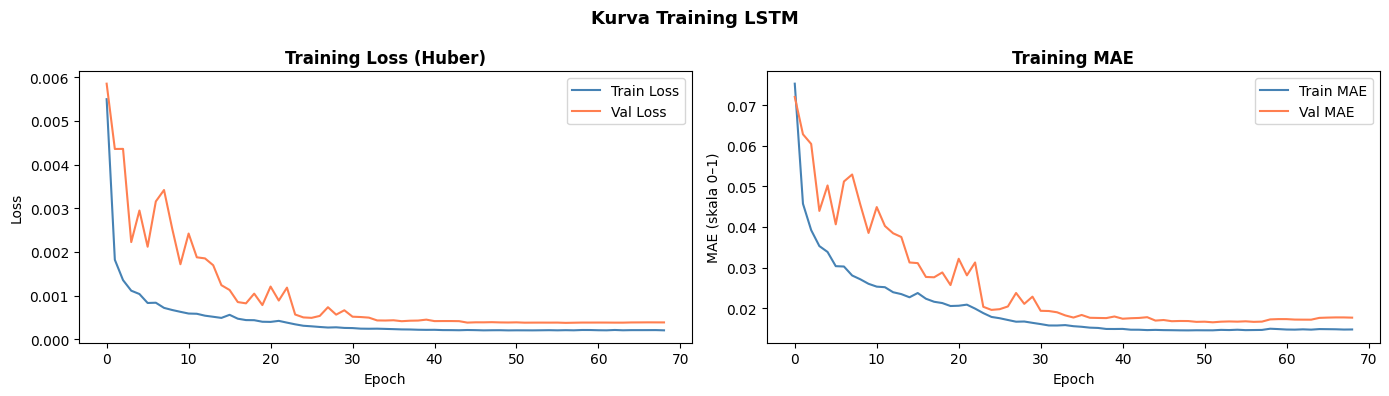

In [ ]:
# ── Plot Training & Validation Loss ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='coral',     linewidth=1.5)
axes[0].set_title('Training Loss (Huber)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

# MAE
axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue', linewidth=1.5)
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='coral',     linewidth=1.5)
axes[1].set_title('Training MAE', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (skala 0–1)')
axes[1].legend()

plt.suptitle('Kurva Training LSTM', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

## 10. Evaluasi Model pada Data Test

Evaluasi dilakukan pada **data test (20% akhir)** — data yang tidak pernah dilihat model selama training.


In [ ]:
# ── Prediksi test set ─────────────────────────────────────────────────────────
y_pred_sc = lstm_model.predict(X_seq_te, batch_size=64, verbose=0).flatten()

# Inverse transform ke skala AQI asli
y_pred_orig = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1)).flatten()
y_true_orig = scaler_y.inverse_transform(y_seq_te.reshape(-1, 1)).flatten()

# Clip agar tidak negatif
y_pred_orig = np.clip(y_pred_orig, 0, None)

print(f"Sampel prediksi : {len(y_pred_orig):,}")

Sampel prediksi : 25,619


In [ ]:
# ── Hitung metrik via evaluate_model (konsisten dengan src/utils.py) ──────────
test_metrics = evaluate_model(y_true_orig, y_pred_orig, "LSTM-Bidirectional")

print("=" * 50)
print("   EVALUASI LSTM — DATA TEST")
print("=" * 50)
for k, v in test_metrics.items():
    unit = '%' if k == 'MAPE' else ''
    print(f"   {k:<8} : {v:.4f}{unit}")
print("=" * 50)

# ── Log experiment ke CSV (konsisten dengan workflow nb05) ────────────────────
lstm_params = {
    "look_back": LOOK_BACK,
    "layers": "BiLSTM(128)+BiLSTM(64)+LSTM(32)",
    "loss": "huber",
    "optimizer": "adam",
    "data_months": 6,
}
log_experiment(
    model_name="LSTM-Bidirectional",
    params=lstm_params,
    metrics=test_metrics,
    log_path="results/experiment_log.csv",
)
print("\n✅ Hasil dicatat ke results/experiment_log.csv")

ValueError: x and y must have same first dimension, but have shapes (25571,) and (25619,)

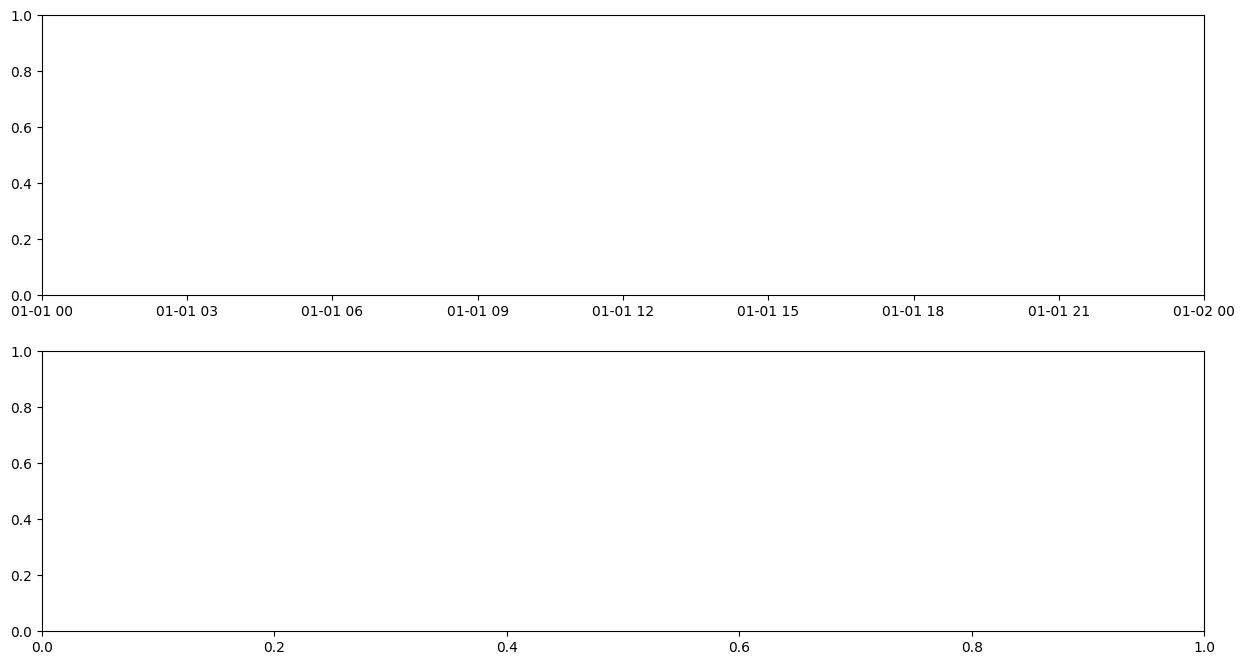

In [ ]:
test_dates = test_df['datetime'].iloc[LOOK_BACK:].values

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Full test set
axes[0].plot(test_dates, y_true_orig, label='Aktual')
axes[0].plot(test_dates, y_pred_orig, label='Prediksi LSTM', linestyle='--')

axes[0].set_title('LSTM — Aktual vs Prediksi (Full Test Set)')
axes[0].legend()

# Zoom 30 hari
zoom_n = min(30 * 24, len(y_true_orig))

axes[1].plot(test_dates[:zoom_n], y_true_orig[:zoom_n], label='Aktual')
axes[1].plot(test_dates[:zoom_n], y_pred_orig[:zoom_n],
             label='Prediksi', linestyle='--')

axes[1].legend()
axes[1].set_title('Zoom 30 Hari Pertama')

plt.tight_layout()
plt.show()

In [ ]:
# ── Scatter plot & residual ───────────────────────────────────────────────────
r2_val = test_metrics['R2']   # ambil dari evaluate_model result

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_true_orig, y_pred_orig, alpha=0.15, s=5, color='steelblue')
lims = [min(y_true_orig.min(), y_pred_orig.min()) - 5,
        max(y_true_orig.max(), y_pred_orig.max()) + 5]
axes[0].plot(lims, lims, 'r--', linewidth=1.2, label='Perfect fit')
axes[0].set_title(f'Scatter: Aktual vs Prediksi  (R²={r2_val:.3f})', fontweight='bold')
axes[0].set_xlabel('Aktual AQI'); axes[0].set_ylabel('Prediksi AQI')
axes[0].legend()

# Residual distribution
residuals = y_pred_orig - y_true_orig
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0,               color='red',    linewidth=1.5, linestyle='--', label='0')
axes[1].axvline(residuals.mean(),color='orange', linewidth=1.5, linestyle='--',
                label=f'Mean={residuals.mean():.2f}')
axes[1].set_title('Distribusi Residual (Prediksi − Aktual)', fontweight='bold')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout(); plt.show()

In [ ]:
# ── Analisis kesalahan per level AQI ─────────────────────────────────────────
def aqi_category(v):
    if v <= 50:   return '0–50 Good'
    elif v <= 100: return '51–100 Moderate'
    elif v <= 150: return '101–150 Unhealthy (Sensitive)'
    elif v <= 200: return '151–200 Unhealthy'
    else:          return '>200 Very Unhealthy'

err_df = pd.DataFrame({'actual': y_true_orig, 'pred': y_pred_orig})
err_df['category'] = err_df['actual'].apply(aqi_category)
err_df['abs_err']  = np.abs(err_df['actual'] - err_df['pred'])

cat_err = err_df.groupby('category').agg(
    Count=('abs_err','count'),
    MAE=('abs_err','mean'),
    MaxErr=('abs_err','max')
).sort_index()

print("\nAnalisis Error per Kategori AQI:")
print(cat_err.round(3).to_string())

## 11. Forecasting AQI 30 Hari ke Depan

### Strategi: Multi-Step Recursive Forecasting

Karena kita butuh prediksi **720 langkah ke depan** (30 hari × 24 jam), kita pakai strategi **recursive/autoregressive**:

1. Ambil **LOOK_BACK (48) jam terakhir** dari data historis sebagai seed sequence
2. Prediksi jam ke-1 → hasilnya masuk ke sequence
3. Prediksi jam ke-2 menggunakan sequence yang sudah diupdate
4. Ulangi hingga 720 jam

**Catatan:** Fitur polutan yang tidak diketahui di masa depan diisi dengan **nilai terakhir yang diketahui** (carry-forward) — asumsi kondisi polutan stabil. Fitur temporal (hour_sin/cos, dll) diisi secara tepat berdasarkan timestamp masa depan.

In [ ]:
FORECAST_HOURS = 30 * 24  # 720 jam

# ── Seed: LOOK_BACK jam terakhir dari seluruh data (train + test) ─────────────
X_all = np.concatenate([X_train, X_test], axis=0)
seed_sequence = X_all[-LOOK_BACK:].copy()   # (LOOK_BACK, n_features) = (48, n_features)

# Mapping nama fitur ke indeks
feat_idx = {f: i for i, f in enumerate(FEATURES)}

# ── Helper: buat fitur temporal untuk timestamp tertentu ─────────────────────
def temporal_features_for(ts):
    """
    Return dict berisi nilai fitur temporal untuk timestamp ts (pd.Timestamp).
    """
    h = ts.hour; m = ts.month; dow = ts.dayofweek

    def get_season(month):
        if month in [12,1,2]:     return 0
        elif month in [3,4,5]:    return 1
        elif month in [6,7,8,9]:  return 2
        else:                     return 3

    return {
        'hour':       h,
        'day':        ts.day,
        'month':      m,
        'dayofweek':  dow,
        'dayofyear':  ts.dayofyear,
        'is_weekend': int(dow >= 5),
        'quarter':    ts.quarter,
        'hour_sin':   np.sin(2*np.pi*h/24),
        'hour_cos':   np.cos(2*np.pi*h/24),
        'month_sin':  np.sin(2*np.pi*m/12),
        'month_cos':  np.cos(2*np.pi*m/12),
        'dow_sin':    np.sin(2*np.pi*dow/7),
        'dow_cos':    np.cos(2*np.pi*dow/7),
        'season_code': get_season(m),
    }

print(f"Forecast horizon : {FORECAST_HOURS} jam = 30 hari")
print(f"Seed sequence    : {seed_sequence.shape}  ({LOOK_BACK} jam × {n_features} fitur)")

In [ ]:
# ── Recursive Forecasting ─────────────────────────────────────────────────────
last_known_dt  = df_model['datetime'].iloc[-1]
forecast_aqi   = []
current_seq    = seed_sequence.copy()   # (LOOK_BACK, n_features) = (48, n_features)

# Nilai fitur non-temporal terakhir (carry-forward untuk polutan dll)
last_row = X_all[-1].copy()

print(f"Mulai dari     : {last_known_dt}")
print(f"Prediksi hingga: {last_known_dt + pd.Timedelta(hours=FORECAST_HOURS)}")
print("\nForecasting...")

for step in range(FORECAST_HOURS):
    # (1) Prediksi 1 langkah ke depan
    input_3d   = current_seq[np.newaxis, :, :]   # (1, LOOK_BACK, n_features)
    pred_scaled = lstm_model.predict(input_3d, verbose=0)[0, 0]
    pred_aqi   = float(scaler_y.inverse_transform([[pred_scaled]])[0, 0])
    pred_aqi   = max(0, pred_aqi)
    forecast_aqi.append(pred_aqi)

    # (2) Bangun baris fitur baru untuk timestamp berikutnya
    next_ts   = last_known_dt + pd.Timedelta(hours=step + 1)
    new_row   = last_row.copy()

    # Update fitur temporal
    tf_vals   = temporal_features_for(next_ts)
    for fname, fval in tf_vals.items():
        if fname in feat_idx:
            new_row[feat_idx[fname]] = fval

    # Update lag-1 AQI dengan prediksi saat ini (scaled)
    for lag_name in ['aqi_lag1']:
        if lag_name in feat_idx:
            new_row[feat_idx[lag_name]] = pred_scaled

    # Geser sequence: drop baris terlama, tambah baris baru
    current_seq = np.vstack([current_seq[1:], new_row])

    if (step + 1) % 120 == 0:
        print(f"  Step {step+1}/{FORECAST_HOURS} | AQI pred: {pred_aqi:.1f}")

print(f"\n✅ Forecasting selesai — {len(forecast_aqi)} prediksi")

In [ ]:
# ── Buat dataframe hasil forecast ─────────────────────────────────────────────
forecast_dates = pd.date_range(
    start=last_known_dt + pd.Timedelta(hours=1),
    periods=FORECAST_HOURS,
    freq='h'   # lowercase 'h' — 'H' deprecated sejak pandas 2.2
)

df_forecast = pd.DataFrame({
    'datetime': forecast_dates,
    'aqi_pred': forecast_aqi
})

# Agregasi harian
df_forecast['date'] = df_forecast['datetime'].dt.date
df_daily_forecast   = df_forecast.groupby('date').agg(
    aqi_mean=('aqi_pred', 'mean'),
    aqi_min=('aqi_pred', 'min'),
    aqi_max=('aqi_pred', 'max'),
    aqi_std=('aqi_pred', 'std')
).reset_index()

df_daily_forecast['date'] = pd.to_datetime(df_daily_forecast['date'])

print(f"Periode forecast : {df_daily_forecast['date'].min().date()} → {df_daily_forecast['date'].max().date()}")
print(f"\nForecast 30 Hari (Harian):")
print(df_daily_forecast.round(2).to_string(index=False))

## 12. Visualisasi Forecast 30 Hari

In [ ]:
# ── Historis harian untuk konteks (60 hari terakhir) ─────────────────────────
df_hist = df_model[['datetime','aqi']].copy()
df_hist['date'] = df_hist['datetime'].dt.date
df_hist_daily   = df_hist.groupby('date')['aqi'].mean().reset_index()
df_hist_daily['date'] = pd.to_datetime(df_hist_daily['date'])
last60 = df_hist_daily.tail(60)

# ── Warna latar berdasarkan kategori AQI ─────────────────────────────────────
def aqi_color(val):
    if val <= 50:   return '#2ecc71'   # hijau — Good
    elif val <= 100: return '#f1c40f'  # kuning — Moderate
    elif val <= 150: return '#e67e22'  # oranye — Unhealthy (Sensitive)
    elif val <= 200: return '#e74c3c'  # merah — Unhealthy
    else:            return '#8e44ad'  # ungu — Very Unhealthy

In [ ]:
# ── Plot utama: Historis + Forecast 30 hari ──────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# Historis
ax.plot(last60['date'], last60['aqi'],
        label='Historis (60 hari)', color='steelblue',
        linewidth=1.8, alpha=0.9, zorder=3)

# Forecast — dengan confidence band dari std
dates_fc = df_daily_forecast['date']
mean_fc  = df_daily_forecast['aqi_mean']
std_fc   = df_daily_forecast['aqi_std'].fillna(0)

ax.plot(dates_fc, mean_fc,
        label='Forecast (30 hari)', color='tomato',
        linewidth=2, linestyle='--', zorder=4)
ax.fill_between(dates_fc,
                np.clip(mean_fc - std_fc, 0, None),
                mean_fc + std_fc,
                alpha=0.18, color='tomato', label='±1 Std (variabilitas harian)')

# Garis pemisah historis/forecast
ax.axvline(last60['date'].iloc[-1], color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(last60['date'].iloc[-1], ax.get_ylim()[1]*0.95,
        ' ← historis | forecast →', fontsize=9, color='gray', va='top')

# Threshold AQI
ax.axhline(50,  color='#2ecc71', linestyle='--', linewidth=0.8, alpha=0.5, label='AQI 50 (Good)')
ax.axhline(100, color='#f1c40f', linestyle='--', linewidth=0.8, alpha=0.5, label='AQI 100 (Moderate)')
ax.axhline(150, color='#e67e22', linestyle='--', linewidth=0.8, alpha=0.5, label='AQI 150 (Unhealthy)')

ax.set_title(f'Forecast AQI 30 Hari ke Depan — {top_city}',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Tanggal'); ax.set_ylabel('AQI')
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

In [ ]:
# ── Kalender heatmap forecast ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

colors = [aqi_color(v) for v in df_daily_forecast['aqi_mean']]
x_pos  = np.arange(len(df_daily_forecast))

bars = ax.bar(x_pos, df_daily_forecast['aqi_mean'],
              color=colors, edgecolor='white', linewidth=0.5, width=0.8)

# Label nilai di atas bar
for bar, val in zip(bars, df_daily_forecast['aqi_mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# X-axis: tampilkan tanggal
ax.set_xticks(x_pos)
ax.set_xticklabels(
    [d.strftime('%d%b') for d in df_daily_forecast['date']],
    fontsize=8
)

# Threshold lines
for thresh, label, color in [(50,'Good','#2ecc71'), (100,'Moderate','#f1c40f'),
                              (150,'Unhealthy','#e67e22')]:
    ax.axhline(thresh, color=color, linestyle='--', linewidth=0.8, alpha=0.6, label=label)

ax.set_title(f'Bar Chart Harian: AQI Forecast 30 Hari — {top_city}', fontweight='bold', fontsize=13)
ax.set_ylabel('AQI (rata-rata harian)')
ax.legend(fontsize=9, loc='upper right')

# Legend kategori warna
from matplotlib.patches import Patch
legend_patches = [
    Patch(color='#2ecc71', label='Good (≤50)'),
    Patch(color='#f1c40f', label='Moderate (51–100)'),
    Patch(color='#e67e22', label='Unhealthy Sensitive (101–150)'),
    Patch(color='#e74c3c', label='Unhealthy (151–200)'),
    Patch(color='#8e44ad', label='Very Unhealthy (>200)'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=8, ncol=2)

plt.tight_layout(); plt.show()

In [ ]:
# ── Distribusi kategori AQI selama 30 hari ───────────────────────────────────
def aqi_cat_label(v):
    if v <= 50:    return 'Good'
    elif v <= 100: return 'Moderate'
    elif v <= 150: return 'Unhealthy (Sensitive)'
    elif v <= 200: return 'Unhealthy'
    else:          return 'Very Unhealthy'

df_daily_forecast['category'] = df_daily_forecast['aqi_mean'].apply(aqi_cat_label)
cat_counts = df_daily_forecast['category'].value_counts()

cat_color_map = {
    'Good': '#2ecc71',
    'Moderate': '#f1c40f',
    'Unhealthy (Sensitive)': '#e67e22',
    'Unhealthy': '#e74c3c',
    'Very Unhealthy': '#8e44ad'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
pie_colors = [cat_color_map.get(c, 'gray') for c in cat_counts.index]
axes[0].pie(cat_counts.values, labels=cat_counts.index, colors=pie_colors,
            autopct='%1.0f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Distribusi Kategori AQI\n(30 Hari Forecast)', fontweight='bold')

# Hourly forecast pattern
df_forecast['hour'] = df_forecast['datetime'].dt.hour
hourly_fc = df_forecast.groupby('hour')['aqi_pred'].mean()
axes[1].plot(hourly_fc.index, hourly_fc.values,
             color='tomato', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(hourly_fc.index, hourly_fc.values, alpha=0.15, color='tomato')
axes[1].set_title('Pola AQI per Jam (Rata-rata 30 Hari Forecast)', fontweight='bold')
axes[1].set_xlabel('Jam'); axes[1].set_ylabel('AQI')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout(); plt.show()

## 13. Ringkasan Hasil & Export

In [ ]:
# ── Ringkasan lengkap ────────────────────────────────────────────────────────
print("=" * 65)
print("          RINGKASAN HASIL LSTM FORECASTING AQI")
print("=" * 65)
print(f"  Kota          : {top_city}")
print(f"  Data          : Hourly, 6 bulan terakhir ({len(df_model):,} record)")
print(f"  Fitur LSTM    : {n_features} fitur")
print(f"  LOOK_BACK     : {LOOK_BACK} jam ({LOOK_BACK // 24} hari)")
print(f"  Horizon       : {FORECAST_HOURS} jam (30 hari)")
print()
print("  Performa Model (Test Set):")
print(f"  {'Metrik':<10} {'Nilai':>10}")
print(f"  {'-'*24}")
for k, v in test_metrics.items():
    unit = '%' if k == 'MAPE' else ''
    print(f"  {k:<10} {v:>9.4f}{unit}")
print()
print("  Forecast Ringkasan (30 Hari):")
print(f"  AQI rata-rata  : {df_daily_forecast['aqi_mean'].mean():.2f}")
print(f"  AQI minimum    : {df_daily_forecast['aqi_min'].min():.2f}")
print(f"  AQI maksimum   : {df_daily_forecast['aqi_max'].max():.2f}")
print()
print("  Distribusi Kategori Forecast:")
for cat, cnt in cat_counts.items():
    print(f"    {cat:<28} : {cnt:>2} hari")
print("=" * 65)

In [ ]:
# ── Export forecast harian ke CSV ─────────────────────────────────────────────
df_export = df_daily_forecast[['date', 'aqi_mean', 'aqi_min', 'aqi_max', 'aqi_std', 'category']].copy()
df_export.columns = ['Tanggal', 'AQI_Mean', 'AQI_Min', 'AQI_Max', 'AQI_Std', 'Kategori']
df_export.to_csv('results/forecast_aqi_30hari.csv', index=False)
print("✅ Forecast disimpan ke 'results/forecast_aqi_30hari.csv'")
print()
print(df_export.to_string(index=False))

In [ ]:
# ── Export forecast per jam ke CSV ────────────────────────────────────────────
df_forecast_export = df_forecast[['datetime', 'aqi_pred']].copy()
df_forecast_export['kategori'] = df_forecast_export['aqi_pred'].apply(aqi_cat_label)
df_forecast_export.to_csv('results/forecast_aqi_hourly_30hari.csv', index=False)
print("✅ Forecast per jam disimpan ke 'results/forecast_aqi_hourly_30hari.csv'")
print(f"   Total baris: {len(df_forecast_export):,}")

In [ ]:
# ── Simpan model & scaler ─────────────────────────────────────────────────────
import joblib

lstm_model.save('models/lstm_aqi_model.h5')

# Prefix "lstm_" agar tidak bentrok dengan robust_scaler.pkl dari nb04
joblib.dump(scaler_X, 'artifacts/lstm_scaler_X.pkl')
joblib.dump(scaler_y, 'artifacts/lstm_scaler_y.pkl')

print("✅ Model & scaler tersimpan:")
print("   models/lstm_aqi_model.h5      — model LSTM")
print("   artifacts/lstm_scaler_X.pkl   — scaler fitur (RobustScaler)")
print("   artifacts/lstm_scaler_y.pkl   — scaler target AQI (MinMaxScaler)")
print()
print("Untuk load ulang:")
print("  model    = tf.keras.models.load_model('models/lstm_aqi_model.h5')")
print("  scaler_X = joblib.load('artifacts/lstm_scaler_X.pkl')")
print("  scaler_y = joblib.load('artifacts/lstm_scaler_y.pkl')")

## Catatan Akhir

### Interpretasi Hasil
- **MAE / RMSE** yang rendah menunjukkan model mampu mengikuti pola AQI per jam dengan baik
- **R²** mendekati 1 menunjukkan model menjelaskan sebagian besar variansi AQI
- **Forecast 30 hari** bersifat **indikatif** — semakin jauh horizon, semakin besar akumulasi error (karena carry-forward polutan)

### Keterbatasan & Future Work
| Keterbatasan | Solusi Potensial |
|---|---|
| Polutan masa depan tidak diketahui (carry-forward) | Integrasikan data prakiraan cuaca / NWP |
| Forecast tidak per-kota (satu seed sequence global) | City-specific seed sequence untuk forecast yang lebih akurat |
| Recursive forecasting accumulates error | Direct multi-output LSTM (prediksi 720 langkah sekaligus) |
| Tidak ada hyperparameter tuning | Optuna / KerasTuner |